In [2]:
#1
student_name = "Nhat Tam Huynh" 
student_id = int(101042941)
has_paid = True
gpa = float(3.61)

courses = ["Programming", "Visualization", "Business Analytics"]
term_info = ("Winter", 2026)
profile = {
    "name":student_name,
    "id":student_id,
    "paid":has_paid,
    "gpa":gpa
}
unique_courses = set(courses)

print("Type of student_name:",type(student_name))
print("\nType of student_id:",type(student_id))
print("\nType of has_paid:",type(has_paid))
print("\nType of gpa:",type(gpa))
print("\nType of courses:", type(courses))
print("\nType of term_info:", type(term_info))
print("\nType of profile:", type(profile))
print("\nType of unique_courses:", type(unique_courses))
print("\nNumber of courses:", len(courses))
enrollment_condition = has_paid and gpa >= 3.0
print("\nMeets enrollment condition:", enrollment_condition)

Type of student_name: <class 'str'>

Type of student_id: <class 'int'>

Type of has_paid: <class 'bool'>

Type of gpa: <class 'float'>

Type of courses: <class 'list'>

Type of term_info: <class 'tuple'>

Type of profile: <class 'dict'>

Type of unique_courses: <class 'set'>

Number of courses: 3

Meets enrollment condition: True


In [1]:
#2 + 3
import pandas as pd

#helper functions
def compute_ctr(clicks, spend):
    if spend == 0:
        return 0
    return clicks / spend

def compute_cvr(conversions, clicks):
    if clicks == 0:
        return 0
    return conversions / clicks

def label_campaign(cvr, cvr_threshold):
    if cvr >= cvr_threshold:
        return "High Performing"
    else:
        return "Needs Improvement"
        
#main function
def analyze_campaigns(csv_file, cvr_threshold):
    df = pd.read_csv(csv_file)
    
    df["CTR"] = 0.0
    df["CVR"] = 0.0
    df["Label"] = ""

    for index, row in df.iterrows():
        clicks = row["Clicks"]
        spend = row["Spend"]
        conversions = row["Conversions"]
        
        ctr = compute_ctr(clicks, spend)
        cvr = compute_cvr(conversions, clicks)

        df.loc[index, "CTR"] = ctr
        df.loc[index, "CVR"] = cvr
        df.loc[index, "Label"] = label_campaign(cvr, cvr_threshold)
    
    high_count = (df["Label"] == "High Performing").sum()
    low_count = (df["Label"] == "Needs Improvement").sum()
    
    print("===== Campaign Summary =====")
    print("Total campaigns:", len(df))
    print("High Performing:", high_count)
    print("Needs Improvement:", low_count)

    best_campaign = df.loc[df["CVR"].idxmax()]
    print("\nBest Campaign:")
    print(best_campaign)
    
    return df

df_result = analyze_campaigns(r"F:\University\Ontario\Programming and Data Processing\Assignment 1\campaign_performance.csv",cvr_threshold=0.03)
#I assume cvr_threshold = 0.03 since that is the mean cvr

===== Campaign Summary =====
Total campaigns: 10
High Performing: 6
Needs Improvement: 4

Best Campaign:
CampaignID                C103
Channel                  Email
Spend                      300
Clicks                     900
Conversions                 45
CTR                        3.0
CVR                       0.05
Label          High Performing
Name: 2, dtype: object


In [19]:
#4
import pandas as pd
campaigns = pd.read_csv(r"F:\University\Ontario\Programming and Data Processing\Assignment 1\campaigns.csv")
performance = pd.read_csv(r"F:\University\Ontario\Programming and Data Processing\Assignment 1\performance.csv")

print("==== Campaigns ====")
print("The first 5 rows:\n",campaigns.head())
print("\nThe columns names:\n",campaigns.columns)
print("\nThe data types:\n",campaigns.dtypes)
print("\nNumber of rows and columns:",campaigns.shape)
print("\n==== Performance ====")
print("The first 5 rows:\n",performance.head())
print("\nThe columns names:\n",performance.columns)
print("\nThe data types:\n",performance.dtypes)
print("\nNumber of rows and columns:",performance.shape)

==== Campaigns ====
The first 5 rows:
   CampaignID    Channel   StartDate     EndDate  Budget
0       C101  Instagram  2026-01-05  2026-01-25    6000
1       C102  GoogleAds  2026-01-10  2026-01-30   12000
2       C103      Email  2026-01-15  2026-02-05    3500
3       C104     TikTok  2026-01-20  2026-02-15    9000
4       C105   LinkedIn  2026-01-25  2026-02-20   15000

The columns names:
 Index(['CampaignID', 'Channel', 'StartDate', 'EndDate', 'Budget'], dtype='object')

The data types:
 CampaignID    object
Channel       object
StartDate     object
EndDate       object
Budget         int64
dtype: object

Number of rows and columns: (8, 5)

==== Performance ====
The first 5 rows:
   CampaignID        Date  Impressions  Clicks  Conversions   Revenue
0       C101  2026-01-10        76615    1637           52   4600.73
1       C101  2026-01-11        94463    5563          265  14595.78
2       C101  2026-01-12        42354     457           21   1697.14
3       C101  2026-01-13      

In [25]:
#5
import pandas as pd
performance_df = pd.read_csv(r"F:\University\Ontario\Programming and Data Processing\Assignment 1\performance.csv")
performance_df["CTR"] = performance_df["Clicks"] / performance_df["Impressions"]
performance_df.to_csv("performance_with_ctr.csv",index = False)

In [10]:
#6
import pandas as pd
campaigns = pd.read_csv(r"F:\University\Ontario\Programming and Data Processing\Assignment 1\campaigns.csv")
performance = pd.read_csv(r"F:\University\Ontario\Programming and Data Processing\Assignment 1\performance.csv")

filtered_campaigns = campaigns[campaigns["Budget"]>5000]
print("Campaigns with budget more than 5000:\n",filtered_campaigns)

performance["CTR"] = performance["Clicks"] / performance["Impressions"]
filtered_performance = performance[performance["CTR"]>0.04]
print("\nPerformance with CTR larger than 0.04:\n",filtered_performance.head())

sorted_campaigns = campaigns.sort_values(by="Budget", ascending=False)
print("\nCampaigns' budget (highest to lowest):\n",sorted_campaigns.head())

sorted_performance = performance.sort_values(by="Revenue", ascending=False)
print("\nPerformance's revenue (highest to lowest):\n",sorted_performance.head())

Campaigns with budget more than 5000:
   CampaignID    Channel   StartDate     EndDate  Budget
0       C101  Instagram  05-01-2026  25-01-2026    6000
1       C102  GoogleAds  10-01-2026  30-01-2026   12000
3       C104     TikTok  20-01-2026  15-02-2026    9000
4       C105   LinkedIn  25-01-2026  20-02-2026   15000
5       C106  Instagram  01-02-2026  18-02-2026    5200
6       C107  GoogleAds  05-02-2026  25-02-2026   18000

Performance with CTR larger than 0.04:
    CampaignID        Date  Impressions  Clicks  Conversions   Revenue  \
1        C101  11-01-2026        94463    5563          265  14595.78   
6        C101  16-01-2026       111806    6200          119   6740.03   
12       C101  22-01-2026       114091    5244          204  17023.72   
14       C102  10-01-2026        62125    2661           74   3578.93   
16       C102  12-01-2026       118022    5527          244  21174.17   

         CTR  
1   0.058891  
6   0.055453  
12  0.045963  
14  0.042833  
16  0.046830  

In [44]:
#7
import pandas as pd
performance_df = pd.read_csv(r"F:\University\Ontario\Programming and Data Processing\Assignment 1\performance.csv")
grouped_performance_df = performance_df.groupby("CampaignID").agg({
    "Impressions": "sum",
    "Clicks": "sum",
    "Conversions": "sum",
    "Revenue": "sum"
})

grouped_performance_df["Average_CTR"] = grouped_performance_df["Clicks"] / grouped_performance_df["Impressions"]

print(grouped_performance_df)

            Impressions  Clicks  Conversions    Revenue  Average_CTR
CampaignID                                                          
C101            1003593   34603         1326   81977.14     0.034479
C102             957899   30613         1404   72597.53     0.031958
C103             846057   27066          873   48064.01     0.031991
C104             736857   23366          891   52774.11     0.031710
C105             921558   36519         1656   81711.17     0.039627
C106            1207383   43870         2102  101428.54     0.036335
C107             828505   31419         1321   62266.53     0.037923
C108             866402   35877         1313   86348.87     0.041409


In [48]:
#8
import pandas as pd
merge_df = campaigns.merge(grouped_performance_df, on="CampaignID",how="left")

final_df = merge_df[[
    "CampaignID",
    "Channel",
    "Budget",
    "Revenue",
    "Average_CTR"
]]

most_profitable = final_df.loc[final_df["Revenue"].idxmax()]
highest_average_CTR = final_df.loc[final_df["Average_CTR"].idxmax()]

print("===== Final Merged DataFrame ====")
print(final_df)
print("\nThe most profitable campaign:\n",most_profitable)
print("\nThe campaign with the highest average CTR:\n",highest_average_CTR)

===== Final Merged DataFrame ====
  CampaignID    Channel  Budget    Revenue  Average_CTR
0       C101  Instagram    6000   81977.14     0.034479
1       C102  GoogleAds   12000   72597.53     0.031958
2       C103      Email    3500   48064.01     0.031991
3       C104     TikTok    9000   52774.11     0.031710
4       C105   LinkedIn   15000   81711.17     0.039627
5       C106  Instagram    5200  101428.54     0.036335
6       C107  GoogleAds   18000   62266.53     0.037923
7       C108      Email    4800   86348.87     0.041409

The most profitable campaign:
 CampaignID          C106
Channel        Instagram
Budget              5200
Revenue        101428.54
Average_CTR     0.036335
Name: 5, dtype: object

The campaign with the highest average CTR:
 CampaignID         C108
Channel           Email
Budget             4800
Revenue        86348.87
Average_CTR    0.041409
Name: 7, dtype: object


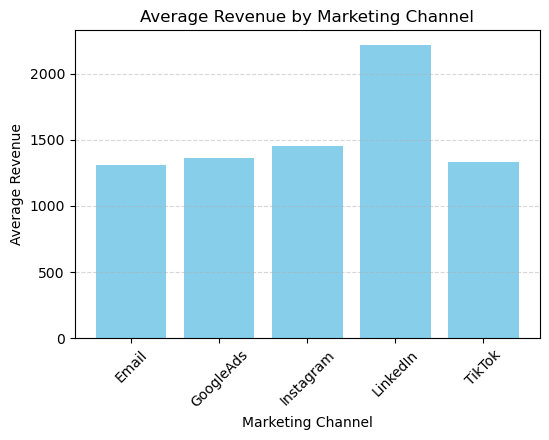

In [64]:
#9.1
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"F:\University\Ontario\Programming and Data Processing\Assignment 1\marketing_engagement.csv")

avg_revenue = df.groupby("Channel")["Revenue"].mean()
plt.figure(figsize=(6,4))
plt.bar(avg_revenue.index, avg_revenue.values, color="skyblue")
plt.title("Average Revenue by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

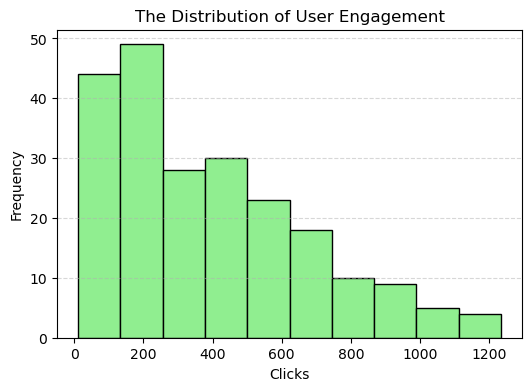

In [58]:
#9.2
plt.figure(figsize=(6,4))
plt.hist(df["Clicks"].dropna(), bins=10, color="lightgreen", edgecolor="black")
plt.title("The Distribution of User Engagement")
plt.xlabel("Clicks")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

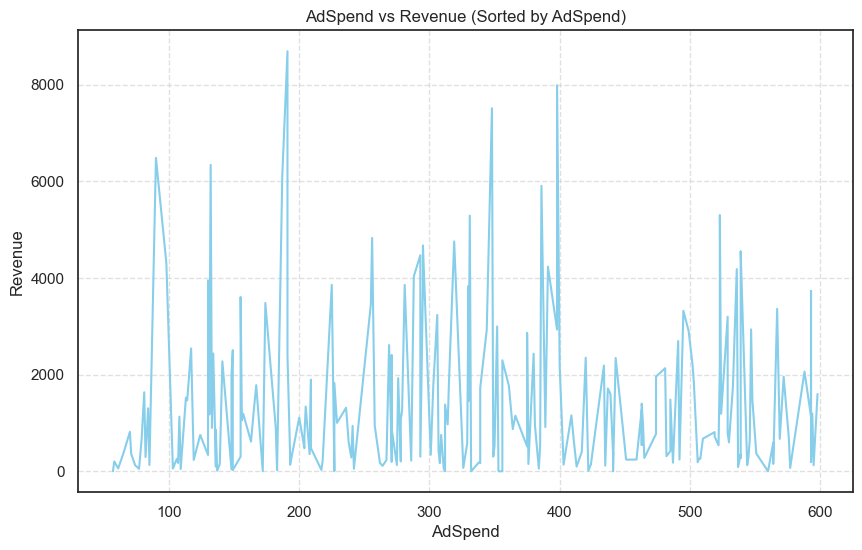

In [73]:
#9.3
sorted_df = df.sort_values("AdSpend")

plt.figure(figsize=(10,6))
plt.plot(sorted_df["AdSpend"],sorted_df["Revenue"], color="skyblue")
plt.title("AdSpend vs Revenue (Sorted by AdSpend)")
plt.xlabel("AdSpend")
plt.ylabel("Revenue")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

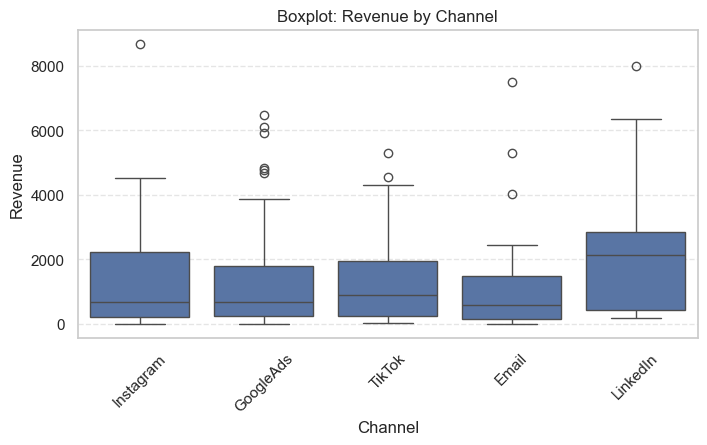

In [67]:
#10.1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r"F:\University\Ontario\Programming and Data Processing\Assignment 1\marketing_engagement.csv")

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Channel", y="Revenue")
plt.title("Boxplot: Revenue by Channel")
plt.xlabel("Channel")
plt.ylabel("Revenue")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)

plt.show()

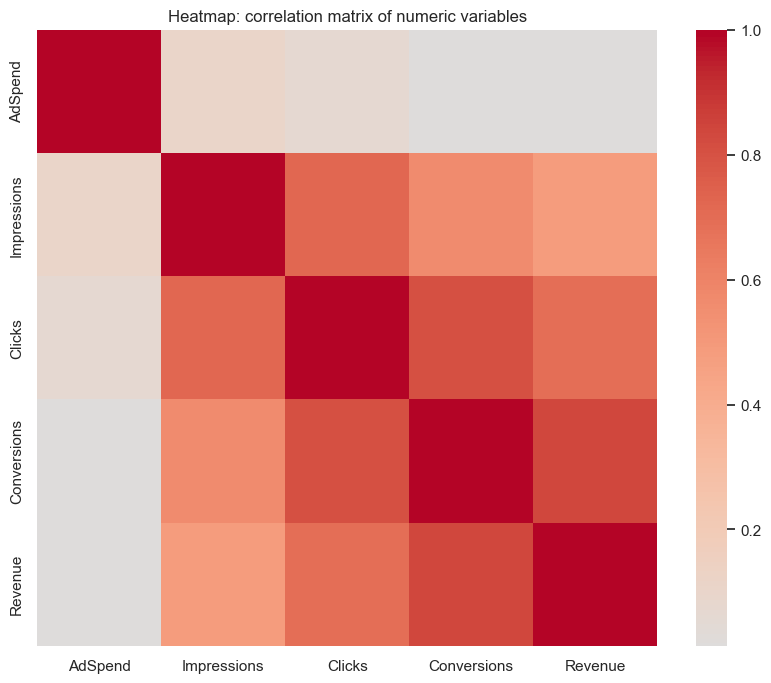

In [69]:
#10.2
sns.set_theme(style="white")
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Heatmap: correlation matrix of numeric variables")

plt.show()

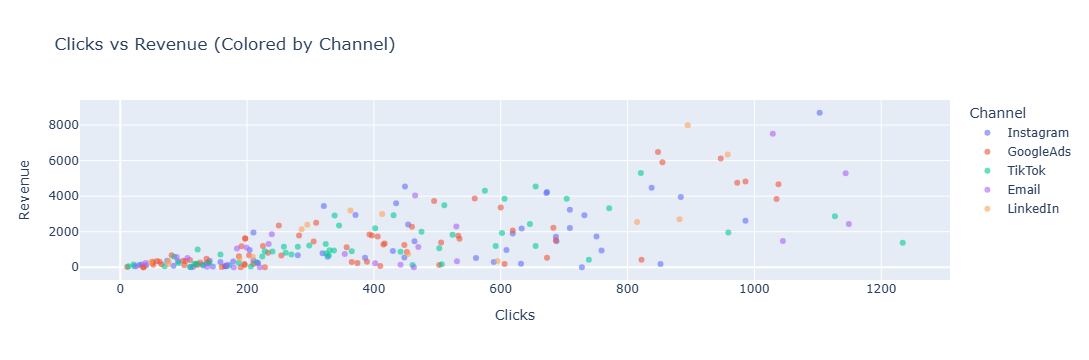

In [72]:
#10.3
import pandas as pd
import plotly.express as px
df = pd.read_csv(r"F:\University\Ontario\Programming and Data Processing\Assignment 1\marketing_engagement.csv")
fig = px.scatter(
    df,
    x="Clicks",
    y="Revenue",
    color="Channel",
    hover_data=["CustomerID"],
    opacity=0.6,
    title="Clicks vs Revenue (Colored by Channel)"
)

fig.show()

In [ ]:
#11
1. Based on the Seaborn boxplot of Revenue by Channel, TikTok shows the highest variability. Because its boxplot has:
- The widest interquartile range (IQR)
- Long whiskers extending far from the median
- It is particularly notable for having many clients that generate revenue ranging from very low to extremely high (from 28.25 to 5303.68)

2. Revenue outliers (from the boxplot):
- Instagram has many extremely high outliers (8694.31).
- GoogleAds also has several high outliers.
- TikTok, Email, and LinkedIn show fewer but still visible outliers.

Clicks outliers (from the histogram):
- Most Clicks fall between ~100 and 600.
- But there are many points above 900, 1000, and even 1200 — especially from TikTok and Email.

3. From the Plotly interactive scatter plot (Clicks vs Revenue):
- There is a positive relationship: higher Clicks generally correspond to higher Revenue.
- However, the relationship is not perfectly linear:
    + Some customers have high Clicks but low Revenue (For example, many TikTok clients have 600–800 clicks but revenue < 300).
    + Others have moderate Clicks but very high Revenue (outliers).
- This suggests that while Clicks contribute to revenue, conversion rate and channel quality also play major roles.

4. No, higher AdSpend does not always result in higher Revenue.
Based on the line chart "AdSpend vs Revenue", the figure fluctuates throughout.
    + Some customers spend a lot but generate very little revenue.
    + Some customers with modest AdSpend produce very high revenue.